In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, precision_recall_curve, recall_score
from sklearn.model_selection import learning_curve, GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
dataset_path = dataset_path = "C:/Users/tamer/.cache/kagglehub/datasets/uciml/pima-indians-diabetes-database/versions/1/diabetes.csv"
df = pd.read_csv(dataset_path)

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 1) Exploratory dataset

int64      7
float64    2
Name: count, dtype: int64


<Axes: ylabel='count'>

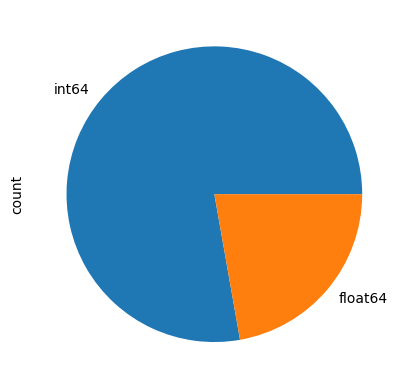

In [4]:
print(df.dtypes.value_counts())
df.dtypes.value_counts().plot.pie() # => pie chart

<Axes: >

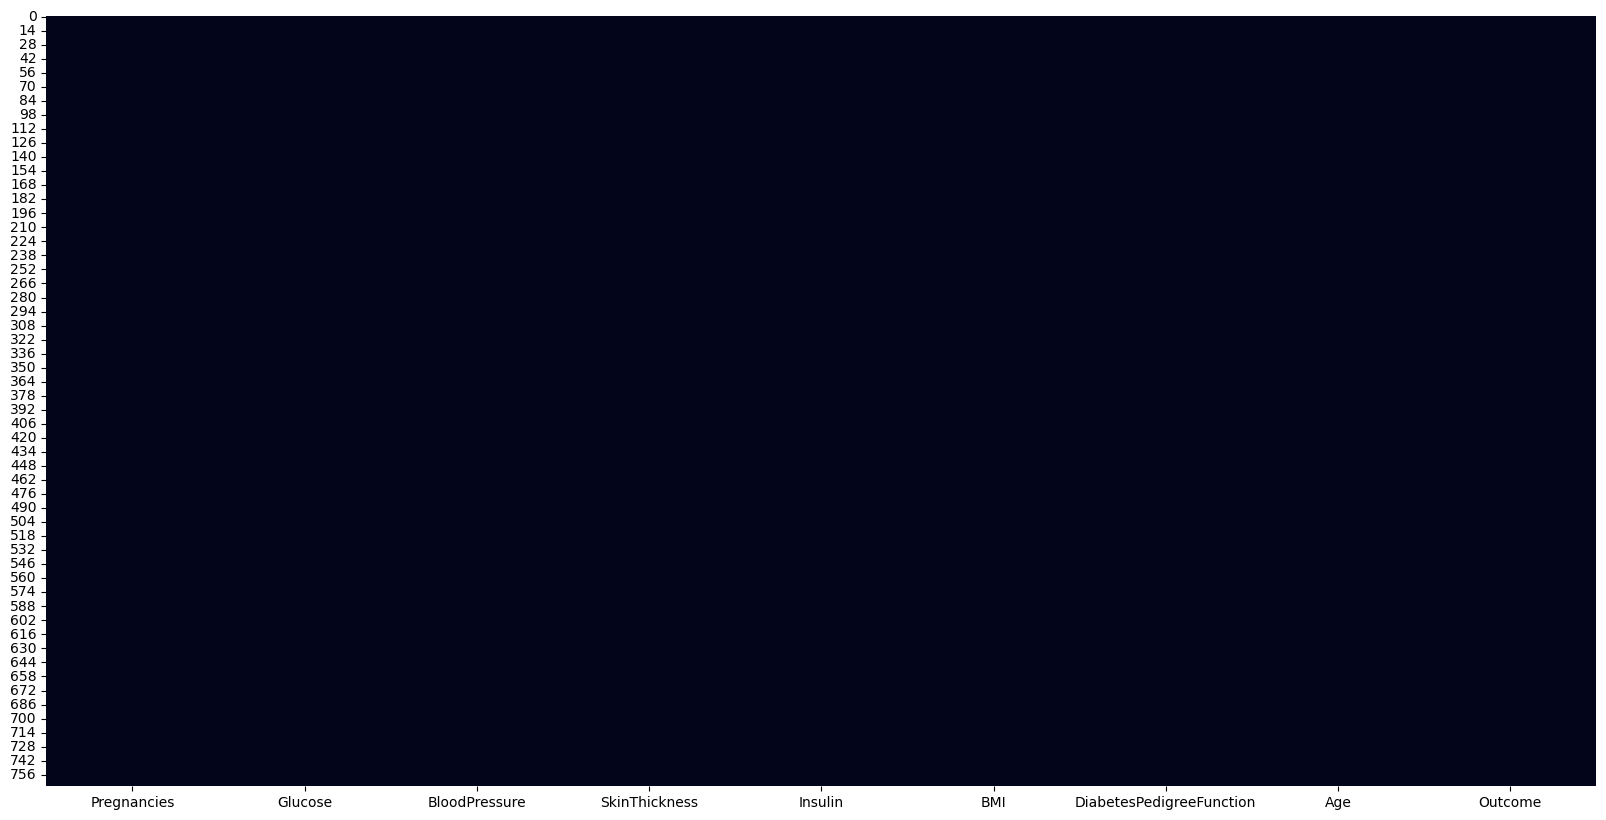

In [5]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar = False)

In [6]:
print(df["Outcome"].value_counts())
print(df["Outcome"].value_counts(normalize=True))

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


# 2) Traintest, cleaning, encoding, preliminary models

In [7]:
trainset, testset = train_test_split(df, test_size = 0.2, random_state=0)

In [9]:
X = df.drop('Outcome', axis = 1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
print("Train set :", X_train.shape)
print("Test set :", X_test.shape)

Train set : (614, 8)
Test set : (154, 8)


In [12]:
model = DecisionTreeClassifier(random_state=0)

In [13]:
def evaluation(model):
    model.fit(X_train, y_train)
    ypred = model.predict(X_test)

    print(confusion_matrix(y_test, ypred))
    print(classification_report(y_test, ypred))

    # evaluation du modèle en fonction du nombre de samples, basé sur le f1 score
    # Evalue si underfit ou overfit
    N, train_score, val_score = learning_curve(model, X_train, y_train, cv=4, scoring='f1', train_sizes=np.linspace(0.1, 1, 10))

    plt.figure(figsize=(10,6))
    # on prend les .means de chaque round de cv. cv = 4 <=> on sépare le dataset en 4 et prend 3 part = train 1 part = test, puis on échange
    plt.plot(N, train_score.mean(axis=1), label = 'train score')
    plt.plot(N, val_score.mean(axis=1), label = 'val score')
    plt.legend()

[[78 24]
 [25 27]]
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       102
           1       0.53      0.52      0.52        52

    accuracy                           0.68       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.68      0.68      0.68       154



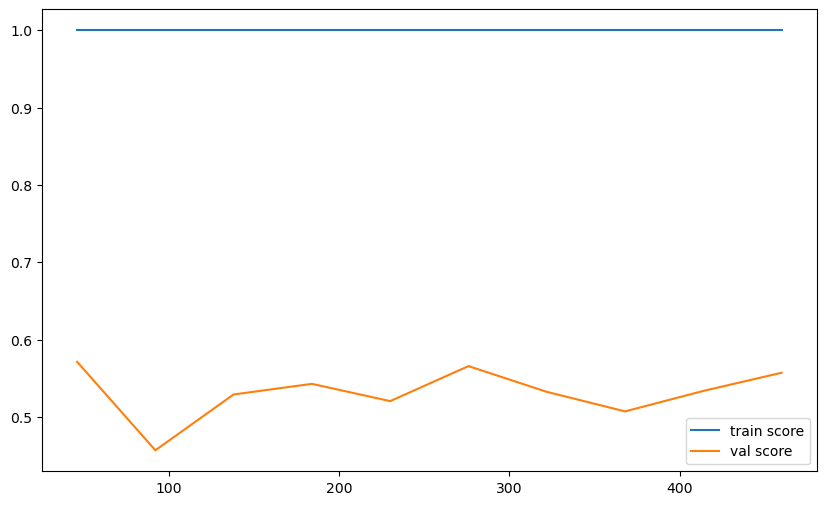

In [14]:
evaluation(model)

In [38]:
pipe = make_pipeline(SelectKBest(f_classif, k = 4), model)

[[80 22]
 [22 30]]
              precision    recall  f1-score   support

           0       0.78      0.78      0.78       102
           1       0.58      0.58      0.58        52

    accuracy                           0.71       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.71      0.71       154



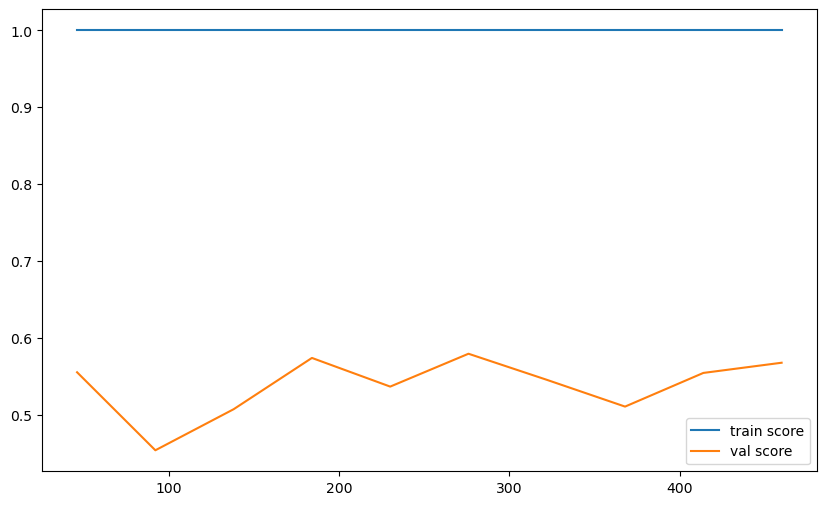

In [37]:
evaluation(pipe)
# 4 variables = meilleur résultats

# 3) Model optimization

In [31]:
RandomForest = make_pipeline(SelectKBest(k=4), RandomForestClassifier(random_state = 0))
AdaBoost = make_pipeline(SelectKBest(k=4), AdaBoostClassifier(random_state = 0))
SVM = make_pipeline(SelectKBest(k=4), StandardScaler(), SVC(random_state = 0))
KNN = make_pipeline(SelectKBest(k=4), StandardScaler(), KNeighborsClassifier())
LR_L1 = make_pipeline(SelectKBest(k=4), StandardScaler(), LogisticRegression(penalty='l1', random_state = 0, solver = 'liblinear'))
LR_L2 = make_pipeline(SelectKBest(k=4), StandardScaler(), LogisticRegression(penalty='l2', random_state = 0, solver = 'liblinear'))
LR_EN = make_pipeline(SelectKBest(k=4), StandardScaler(), LogisticRegression(penalty='elasticnet', l1_ratio=0.5, random_state = 0, solver = 'saga'))


dict_of_models = {'RandomForest' : RandomForest, 
                  'AdaBoost' : AdaBoost, 
                  'SVM' : SVM, 
                  'KNN' : KNN,
                  'LR_L1' : LR_L1,
                  'LR_L2' : LR_L2,
                  'LR_EN' : LR_EN
                 }

#SVC best

[[86 16]
 [19 33]]
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       102
           1       0.67      0.63      0.65        52

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



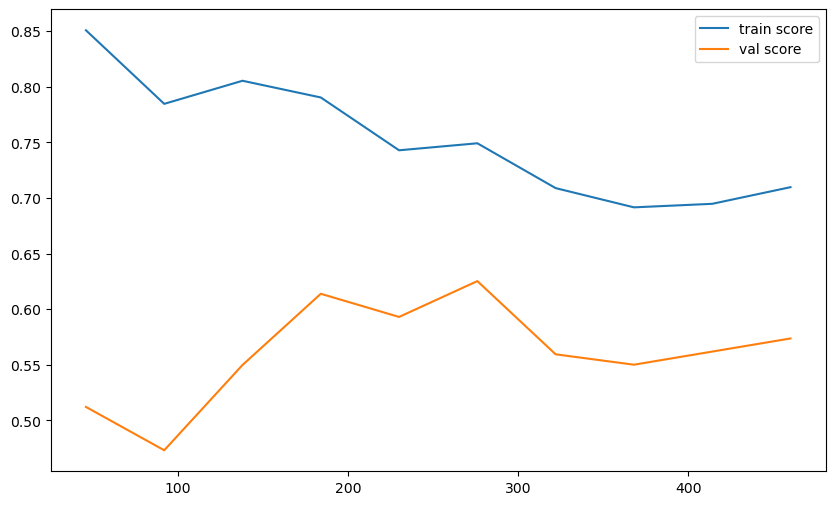

In [33]:
evaluation(SVM)

In [34]:
hyper_params = {'svc__gamma': [1e-3, 1e-4],
                'svc__C' : [1, 10, 100, 1000],
               'selectkbest__k' : range(2, 8)}

In [ ]:
grid = GridSearchCV(SVM, cv = 4, param_grid=hyper_params, scoring='precision')
grid.fit(X_train, y_train)
print(grid.best_params_)

[[86 16]
 [20 32]]
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       102
           1       0.67      0.62      0.64        52

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



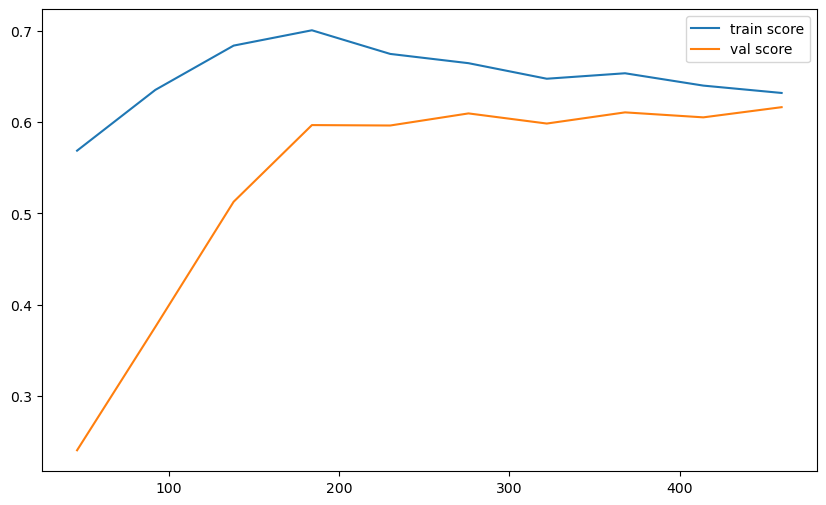

In [52]:
evaluation(grid.best_estimator_)